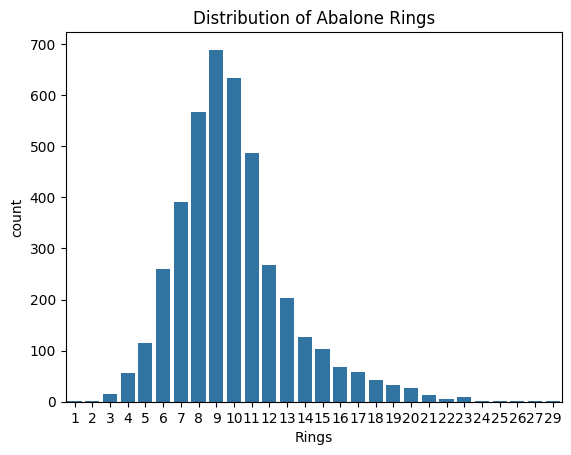

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('abalone.data', header=None, names=['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Rings'])

# Data cleaning and preprocessing
data['Sex'] = data['Sex'].map({'M': 0, 'F': 1, 'I': 2})
X = data.drop('Rings', axis=1)
y = data['Rings']

# Train, validation, test split
# Removing the stratify parameter to avoid the error.
# This might lead to class imbalance in the splits.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Visualize the data
sns.countplot(x='Rings', data=data)
plt.title('Distribution of Abalone Rings')
plt.show()

In [23]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size)

    def forward(self, X):
        self.hidden = relu(np.dot(X, self.weights_input_hidden))
        self.output = softmax(np.dot(self.hidden, self.weights_hidden_output))
        return self.output


In [7]:
def backpropagate(self, X, y, learning_rate):
    # Compute gradients and update weights
    # Calculate output layer error
    output_error = self.output - y
    hidden_error = np.dot(output_error, self.weights_hidden_output.T) * (self.hidden > 0)  # ReLU derivative

    # Update weights
    self.weights_hidden_output -= learning_rate * np.dot(self.hidden.T, output_error)
    self.weights_input_hidden -= learning_rate * np.dot(X.T, hidden_error)


In [8]:
def train(self, X, y, epochs, learning_rate):
    for epoch in range(epochs):
        for i in range(len(X)):
            output = self.forward(X[i:i+1])
            self.backpropagate(X[i:i+1], y[i:i+1], learning_rate)


In [9]:
def predict(self, X):
    output = self.forward(X)
    return np.argmax(output, axis=1)

def accuracy(self, X, y):
    preds = self.predict(X)
    return np.mean(preds == y)


#Q2

In [10]:
import torch
from torchvision import datasets, transforms

# Define transformations for the training set
train_transforms = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Define transformations for the testing and validation sets
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the datasets
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=test_transforms)


Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.55MB/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



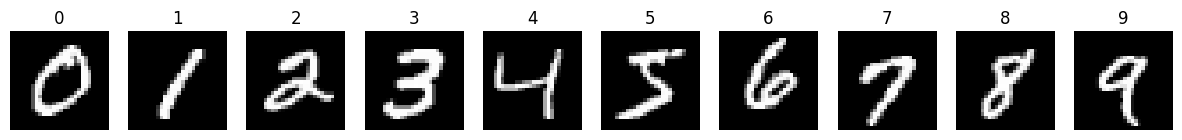

In [12]:
import matplotlib.pyplot as plt

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Plot one image of each digit
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(train_dataset.data[train_dataset.targets == i][0], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(i)
plt.show()


In [13]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 32 * 7 * 7)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [15]:
def train_model(model, train_loader, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')


In [16]:
# Train MLP
mlp_model = MLP()
train_model(mlp_model, train_loader, epochs=5)

# Train CNN
cnn_model = CNN()
train_model(cnn_model, train_loader, epochs=5)


Epoch [1/5], Loss: 0.7458, Accuracy: 76.62%
Epoch [2/5], Loss: 0.3192, Accuracy: 90.28%
Epoch [3/5], Loss: 0.2420, Accuracy: 92.65%
Epoch [4/5], Loss: 0.2112, Accuracy: 93.65%
Epoch [5/5], Loss: 0.1883, Accuracy: 94.29%
Epoch [1/5], Loss: 0.3235, Accuracy: 89.82%
Epoch [2/5], Loss: 0.0993, Accuracy: 96.92%
Epoch [3/5], Loss: 0.0744, Accuracy: 97.68%
Epoch [4/5], Loss: 0.0574, Accuracy: 98.28%
Epoch [5/5], Loss: 0.0493, Accuracy: 98.48%


In [17]:
def train_model_with_logging(model, train_loader, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses, accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = running_loss / len(train_loader)
        accuracy = 100 * correct / total
        losses.append(avg_loss)
        accuracies.append(accuracy)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

    return losses, accuracies


Epoch [1/5], Loss: 0.1759, Accuracy: 94.70%
Epoch [2/5], Loss: 0.1674, Accuracy: 94.81%
Epoch [3/5], Loss: 0.1584, Accuracy: 95.26%
Epoch [4/5], Loss: 0.1462, Accuracy: 95.58%
Epoch [5/5], Loss: 0.1406, Accuracy: 95.71%
Epoch [1/5], Loss: 0.0450, Accuracy: 98.58%
Epoch [2/5], Loss: 0.0402, Accuracy: 98.73%
Epoch [3/5], Loss: 0.0356, Accuracy: 98.88%
Epoch [4/5], Loss: 0.0328, Accuracy: 98.94%
Epoch [5/5], Loss: 0.0319, Accuracy: 99.03%


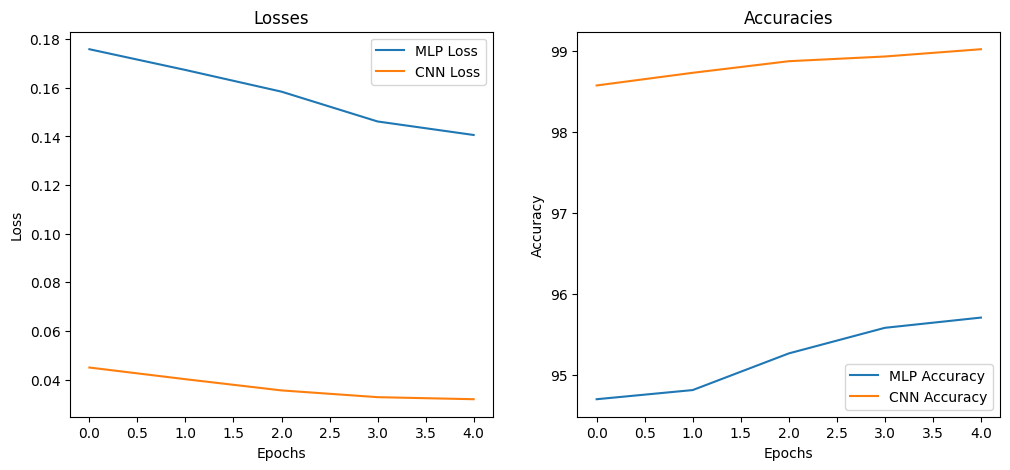

In [18]:
# After training the models, plot the loss and accuracy
import matplotlib.pyplot as plt

# MLP training
mlp_losses, mlp_accuracies = train_model_with_logging(mlp_model, train_loader, epochs=5)

# CNN training
cnn_losses, cnn_accuracies = train_model_with_logging(cnn_model, train_loader, epochs=5)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_losses, label='MLP Loss')
plt.plot(cnn_losses, label='CNN Loss')
plt.title('Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_accuracies, label='MLP Accuracy')
plt.plot(cnn_accuracies, label='CNN Accuracy')
plt.title('Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [21]:
def visualize_predictions(model, test_loader, device): # Added device as an argument
    model.eval()
    correct_images = []
    incorrect_images = []
    correct_labels = []
    incorrect_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device) # Now device is defined
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            for i in range(len(labels)):
                if predicted[i] == labels[i]:
                    correct_images.append(images[i].cpu())
                    correct_labels.append(labels[i].cpu())
                else:
                    incorrect_images.append(images[i].cpu())
                    incorrect_labels.append(labels[i].cpu())

    return correct_images, correct_labels, incorrect_images, incorrect_labels

# Before calling visualize_predictions, define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Visualizing predictions for MLP, passing the device
correct_images_mlp, correct_labels_mlp, incorrect_images_mlp, incorrect_labels_mlp = visualize_predictions(mlp_model, test_loader, device)

# Visualizing predictions for CNN, passing the device
correct_images_cnn, correct_labels_cnn, incorrect_images_cnn, incorrect_labels_cnn = visualize_predictions(cnn_model, test_loader, device)